### This notebook is reformed, the first part is from an old analysis of empirical p-values, the second is a new one using t to z conversion (for plots sake), stouffer method for p val aggregation, maybe add it to fisher

NameError: name 'empirical_pvals_df' is not defined

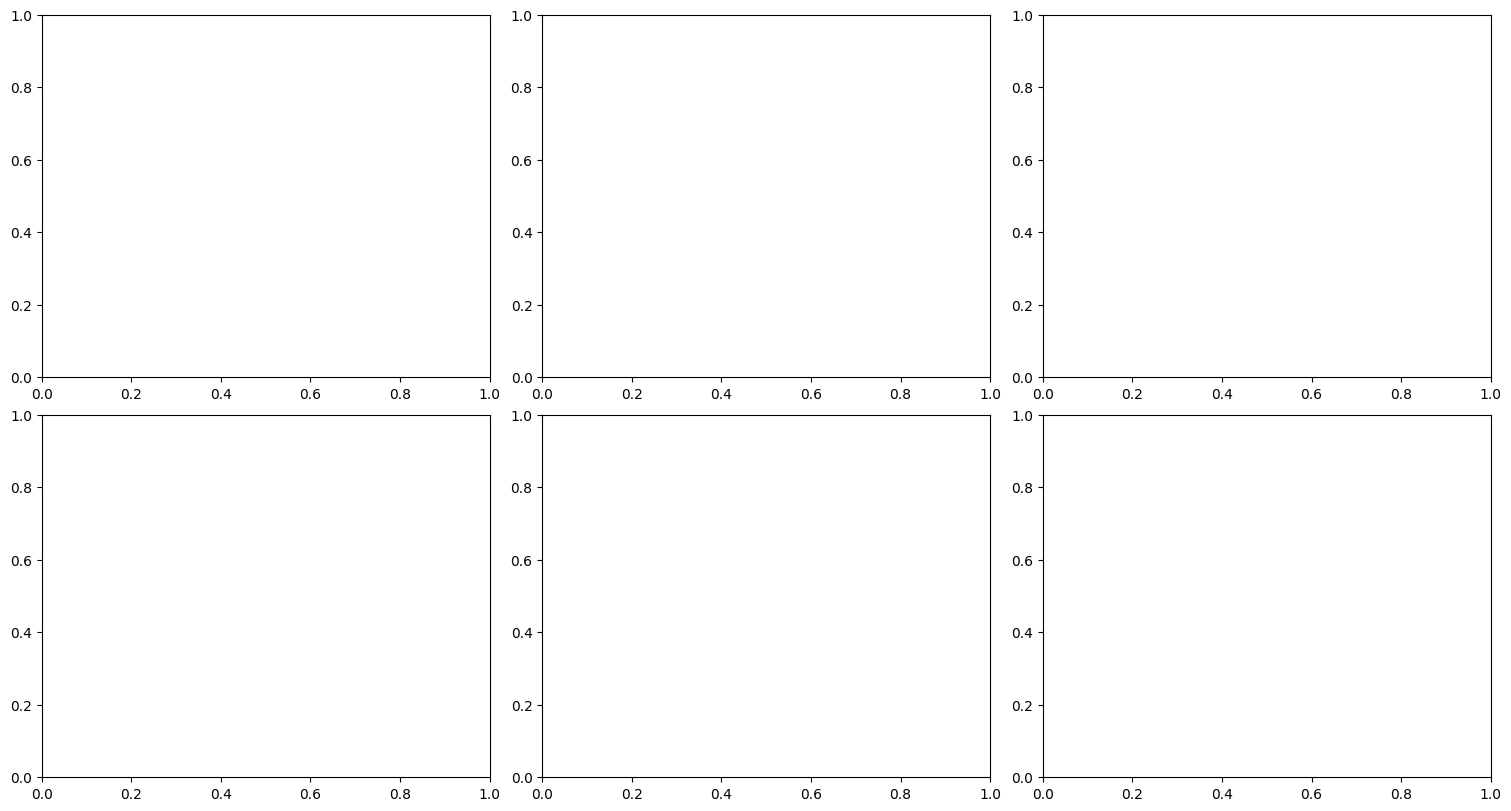

In [4]:
import matplotlib.pyplot as plt
import numpy as np

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '1min-1min', '30s-30s']
n = len(light_regimes)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4), constrained_layout=True)
axes = axes.flatten()

for i, light in enumerate(light_regimes):
    ax = axes[i]
    pvals = empirical_pvals_df[empirical_pvals_df['light_regime'] == light]['empirical_p_value'].dropna()

    ax.hist(pvals, bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(light)
    ax.set_xlabel('Empirical p-value')
    ax.set_ylabel('Count')

    for q in [5, 25, 50, 75, 85, 95]:
        perc = np.percentile(pvals, q)
        ax.axvline(perc, color='red', linestyle='--')
        ax.text(perc, ax.get_ylim()[1]*0.9, f'{q}%', rotation=90, color='red', va='top', ha='right')

# Supprimer les cases vides si le nombre de régimes est < 9 3la 3jaaj
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Empirical p-value distributions per light regime', fontsize=16)
plt.show()


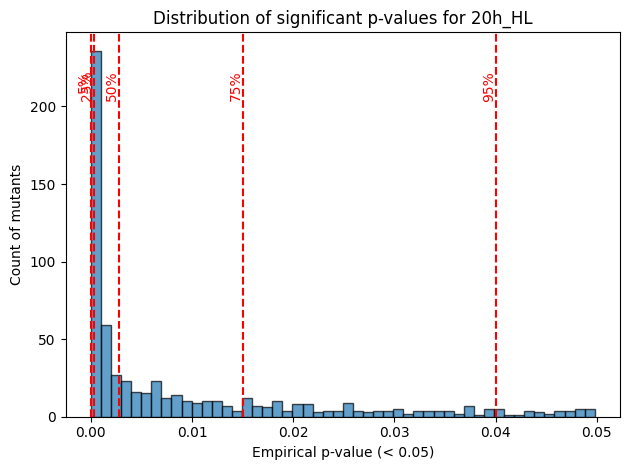

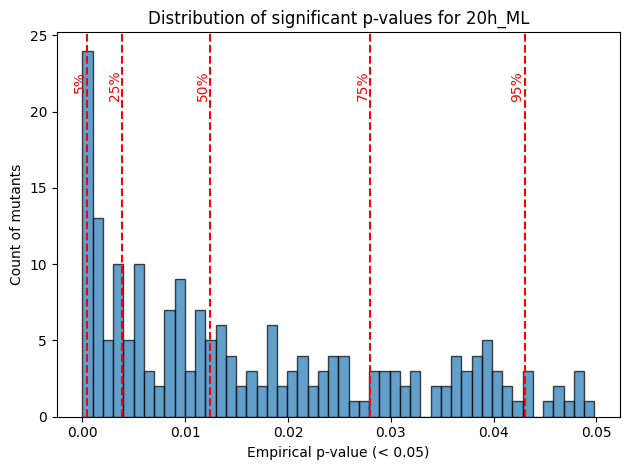

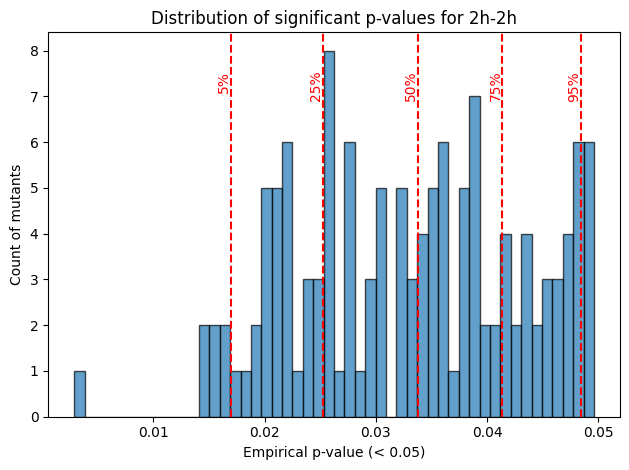

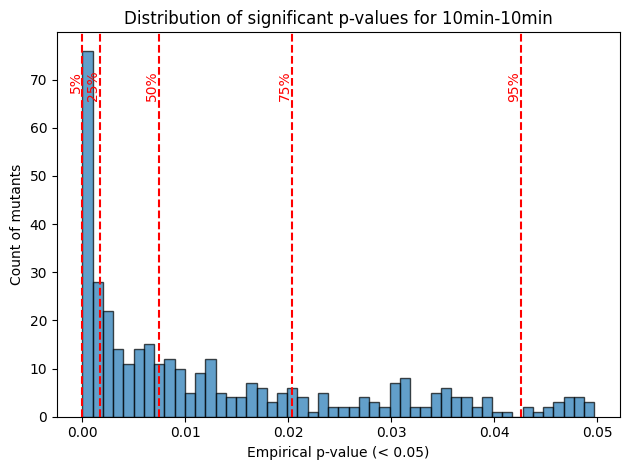

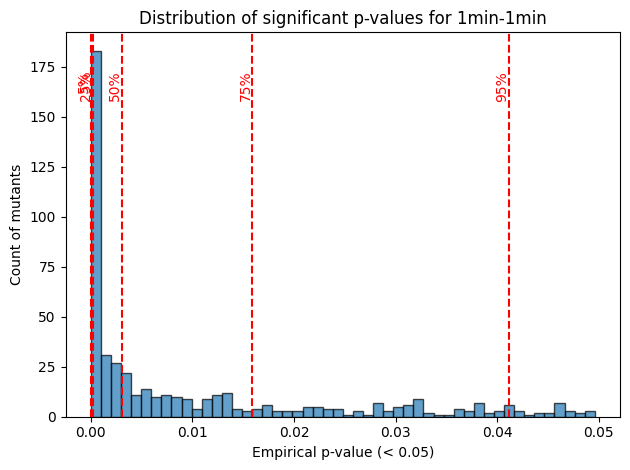

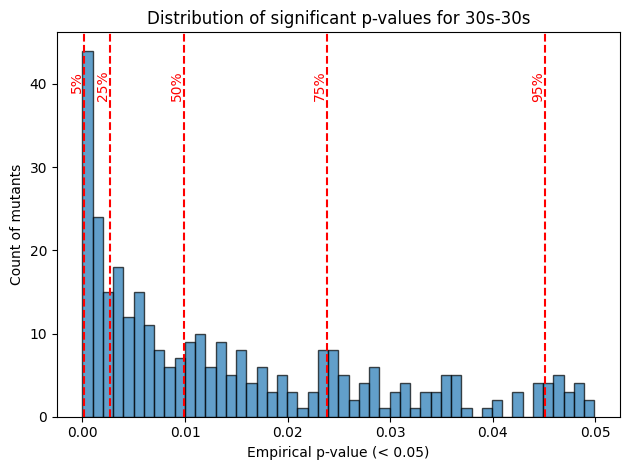

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '1min-1min', '30s-30s']

for light in light_regimes:
    # Filter for p-values < 0.05
    pvals = empirical_pvals_df[
        (empirical_pvals_df['light_regime'] == light) &
        (empirical_pvals_df['empirical_p_value'] < 0.05)
    ]['empirical_p_value']

    if pvals.empty:
        print(f"No p-values < 0.05 for {light}")
        continue

    # Plot histogram with more bins
    plt.hist(pvals, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Empirical p-value (< 0.05)')
    plt.ylabel('Count of mutants')
    plt.title(f'Distribution of significant p-values for {light}')

    # Add percentile lines
    for q in [5, 25, 50, 75, 95]:
        perc = np.percentile(pvals, q)
        plt.axvline(perc, color='red', linestyle='--')
        plt.text(perc, plt.ylim()[1]*0.9, f'{q}%', rotation=90, color='red', va='top', ha='right')

    plt.tight_layout()
    plt.show()


In [ ]:
# empirical_pvals_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/empirical_pvals_PHASE2.csv', index=False)

## 1 p value per gene (pooled/absolute)

Group 1: all WT slopes under that light regime

Group 2: all individual slopes from all mutant_IDs belonging to that gene across all plates under the same light regime

So you do a 2-sample t-test between:

mutated_genes == gene

mutated_genes startswith WT

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# === Load data ===
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')
#data=data[(data['plate'].astype(str).str.startswith('3', na=False))]
print(data['plate'].unique())
# === Clean ===
data = data[data['mutated_genes'].notna() & data['y2_slope'].notna()]
data['plate'] = data['plate'].astype(str)

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min','5min-5min', '1min-5min', '1min-1min', '30s-30s']

results = []

for regime in light_regimes:
    regime_data = data[data['light_regime'] == regime]
    
    # WT group (all plates)
    wt_slopes = regime_data[regime_data['mutated_genes'].str.startswith('WT')]['y2_slope'].dropna()
    if len(wt_slopes) < 2:
        continue
    
    for gene, group in regime_data[~regime_data['mutated_genes'].str.startswith('WT')].groupby('mutated_genes'):
        mut_slopes = group['y2_slope'].dropna()
        if len(mut_slopes) < 2:
            continue
        
        t_stat, p_val = ttest_ind(mut_slopes, wt_slopes, equal_var=True)

        results.append({
            'mutated_genes': gene,
            'light_regime': regime,
            'n_mutant_slopes': len(mut_slopes),
            'n_wt_slopes': len(wt_slopes),
            'mut_mean': mut_slopes.mean(),
            'wt_mean': wt_slopes.mean(),
            't_stat': t_stat,
            'p_value': p_val
        })

# === Make dataframe ===
gene_regime_df = pd.DataFrame(results)
gene_regime_df['FDR'] = multipletests(gene_regime_df['p_value'], method='fdr_bh')[1]

# === Save ===
gene_regime_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_level_ttest_pooled.csv', index=False)


['31v3' '32v1' '30v1' '30v3' '32v3' '32v2' '31v2' '99v2_2' '99v3' '99v1'
 '99v2_1' '30v1_1' '30v2' '30v1_2' '31v1' '99v2' '30v3_1' '30v3_2']


# gene two sample test, WT distrib vs gene per plate (1 p value per gene per plate), just for the visualistaion sake

Group 1: all WT slopes on that plate and light regime

Group 2: average slope for each mutant_ID belonging to that gene on that plate and light regime

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Load and clean
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')
#data=data[(data['plate'].astype(str).str.contains('3', na=False))]

# Remplacer les valeurs de 'mutated_genes' par 'WT' lorsque 'mutant_ID' est égal à 'WT'
data.loc[data['mutant_ID'] == 'WT', 'mutated_genes'] = 'WT'
#data = data[~(data['plate'].astype(str).str.contains('33', na=False))]
data = data[data['mutated_genes'].notna() & data['y2_slope'].notna()]
data['plate'] = data['plate'].astype(str)
data['big_plate'] = data['plate'].str.split('v').str[0]

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min','5min-5min', '1min-5min', '1min-1min', '30s-30s']

results = []

for regime in light_regimes:
    regime_data = data[data['light_regime'] == regime]

    for (gene, big_plate), group in regime_data[~regime_data['mutated_genes'].str.startswith('WT')].groupby(['mutated_genes', 'big_plate']):
        
        # Mutant means: average across replicates for each mutant_ID
        mutant_means = (
            group.groupby('mutant_ID')['y2_slope']
            .mean()
            .reset_index(name='slope')
        )

        if len(mutant_means) < 2:
            continue

        # WT means: average across same well_id across v1/v2/v3 of the big_plate
        wt_group = regime_data[
            (regime_data['big_plate'] == big_plate) &
            (regime_data['mutated_genes'].str.startswith('WT'))
        ]

        if 'well_id' not in wt_group.columns:
            raise ValueError("You must have a 'well_id' column to average WT by well position.")

        wt_means = (
            wt_group.groupby('well_id')['y2_slope']
            .mean()
            .reset_index(name='slope')
        )

        if len(wt_means) < 2:
            continue

        # Welch t-test
        t_stat, p_val = ttest_ind(mutant_means['slope'], wt_means['slope'], equal_var=False)

        results.append({
            'mutated_genes': gene,
            'big_plate': big_plate,
            'light_regime': regime,
            'n_mutants': len(mutant_means),
            'n_wts': len(wt_means),
            'mut_mean': mutant_means['slope'].mean(),
            'wt_mean': wt_means['slope'].mean(),
            't_stat': t_stat,
            'p_value': p_val
        })


# Compile results
df = pd.DataFrame(results)
df['FDR'] = multipletests(df['p_value'], method='fdr_bh')[1]

df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_level_ttest_by_bigplate_balanced.csv', index=False)

### Mutant z scores and stouffer analyis

focus rn only on phase 2 and then we'll 

In [9]:
import pandas as pd
import numpy as np
from statsmodels.stats.multitest import multipletests

# Load and clean
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')
data = data[data['mutated_genes'].notna() & data['y2_slope'].notna()]
data['plate'] = data['plate'].astype(str)
data['big_plate'] = data['plate'].str.split('v').str[0]

light_regimes = ['20h_HL','20h_ML','2h-2h','10min-10min',
                 '5min-5min','1min-5min','1min-1min','30s-30s']

results = []

for regime in light_regimes:
    regime_data = data[data['light_regime'] == regime]

    # WT group: averaged by well_id across ALL plates
    if 'well_id' not in regime_data.columns:
        raise ValueError("Expected a 'well_id' column in data.")
    
    wt_means = (
        regime_data[regime_data['mutated_genes'].str.startswith('WT')]
        .groupby('well_id')['y2_slope']
        .mean()
        .reset_index(name='slope')
    )
    if len(wt_means) < 2:
        continue
    wt_values = wt_means['slope'].values
    mean_wt = wt_values.mean()
    var_wt = wt_values.var(ddof=1)
    n_wt = len(wt_values)

    # Loop over each gene
    for gene, group in regime_data[~regime_data['mutated_genes'].str.startswith('WT')].groupby('mutated_genes'):
        z_scores = []

        for mutant_id, mutant_group in group.groupby('mutant_ID'):
            mut_values = mutant_group['y2_slope'].dropna().values
            n_mut = len(mut_values)
            if n_mut < 2:
                continue

            mean_mut = mut_values.mean()
            var_mut = mut_values.var(ddof=1)

            # Direct Welch-style z-score
            denom = np.sqrt(var_mut/n_mut + var_wt/n_wt)
            if denom == 0:
                continue
            z_i = (mean_mut - mean_wt) / denom
            z_scores.append(z_i)

        if not z_scores:
            continue

        z_scores = np.array(z_scores)

        # === Covariance-adjusted Stouffer ===
        if len(z_scores) > 1:
            Sigma = np.cov(z_scores, rowvar=False, ddof=1)
            if np.ndim(Sigma) == 0:
                Sigma = np.array([[Sigma]])
            denom = np.sqrt(np.sum(Sigma))  # 1^T Σ 1
        else:
            denom = np.sqrt(len(z_scores))  # fallback for 1 mutant

        combined_z = np.sum(z_scores) / denom
        combined_p = 2 * (1 - norm.cdf(abs(combined_z)))  # for reporting

        results.append({
            'mutated_genes': gene,
            'light_regime': regime,
            'n_mutants': len(z_scores),
            'n_wts': n_wt,
            'mut_mean': group['y2_slope'].mean(),
            'wt_mean': mean_wt,
            'combined_z': combined_z,
            'combined_p': combined_p
        })

# Build results dataframe
df = pd.DataFrame(results)
df['FDR'] = multipletests(df['combined_p'], method='fdr_bh')[1]

# Save
df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_level_stouffer_cov.csv', index=False)


In [6]:
full_df = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_level_ttest_pooled.csv')
full_df = full_df[full_df['FDR'] < 0.05]
data = full_df
data_clean = data[~data['mutated_genes'].isna() & ~data['light_regime'].isna()]

gene_counts = data_clean.groupby('light_regime')['mutated_genes'].nunique().reset_index()

gene_counts.columns = ['light_regime', 'unique_gene_count']

print(gene_counts)
full_df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/DifferentTestGenes3/all_genelevel_stouffer_results_FDR05_rawslopes_phase1.csv', index=False)

  light_regime  unique_gene_count
0  10min-10min                286
1    1min-1min                285
2    1min-5min                268
3       20h_HL                428
4       20h_ML                443
5        2h-2h                325
6      30s-30s                283
7    5min-5min                178


/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_655014/1904196064.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['combined_p'] = -np.log10(filtered_df['combined_p'])
/tmp/ipykernel_655014/1904196064.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['combined_z'] = filtered_df['combined_z']


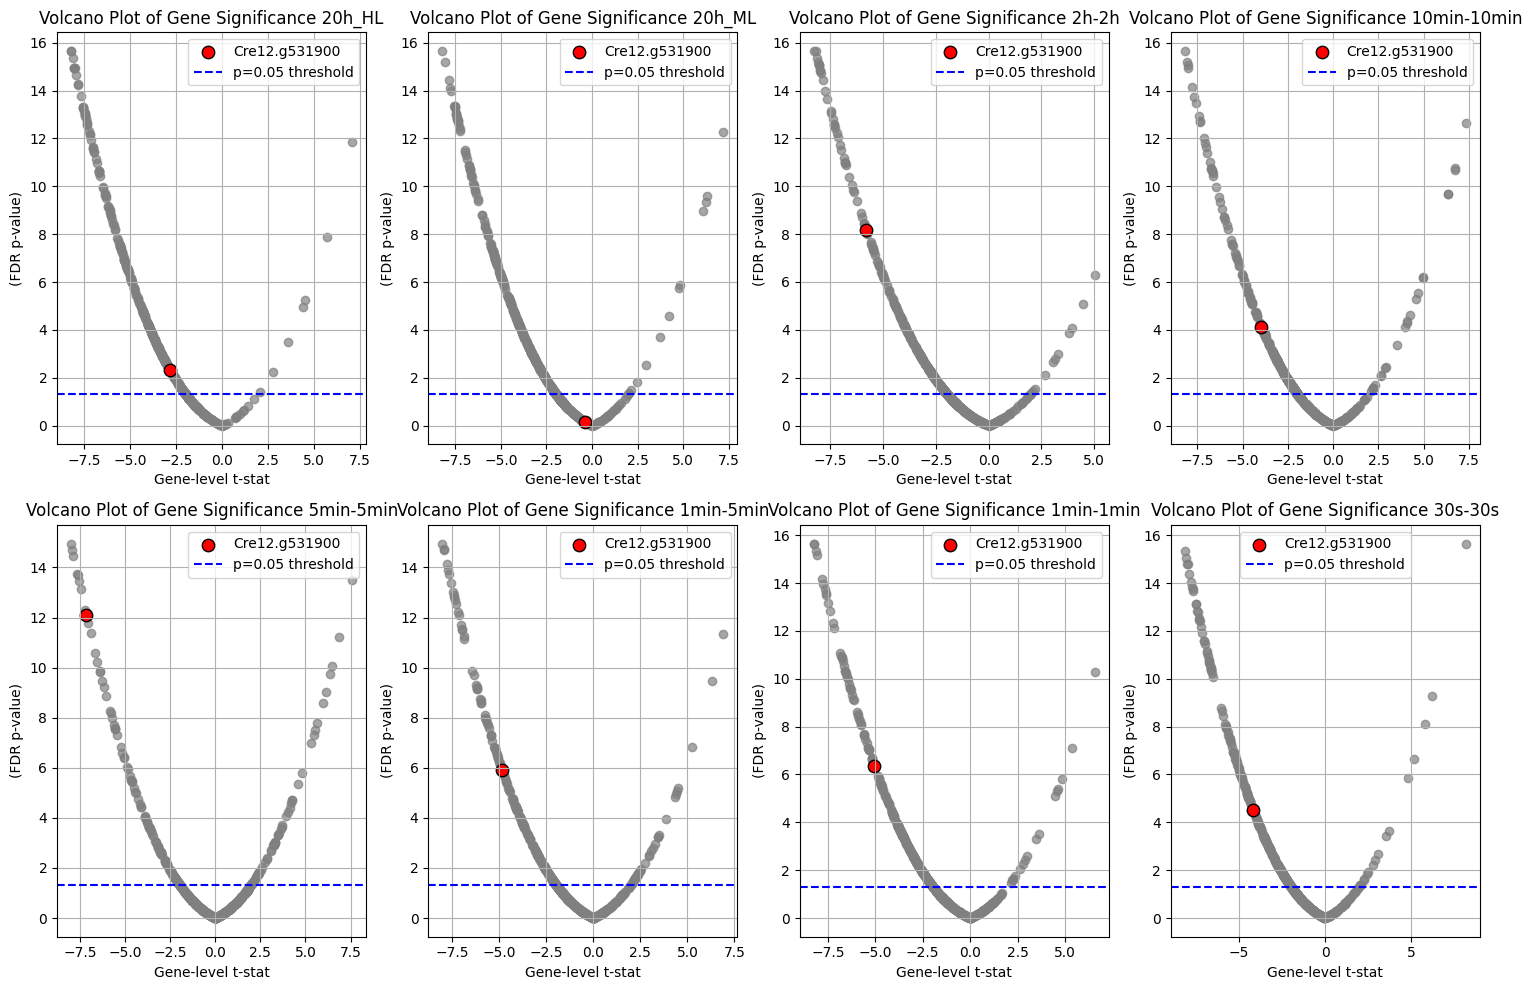

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

np.random.seed(42)
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
example_df = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_level_stouffer_cov.csv')

n_cols = 4
n_rows = int(np.ceil(len(light_regimes) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows), squeeze=False)

for i, light in enumerate(light_regimes):
    row, col = divmod(i, n_cols)
    ax = axes[row][col]
    
    filtered_df = example_df[example_df['light_regime'] == light]
    
    filtered_df['combined_p'] = -np.log10(filtered_df['combined_p'])
    #filtered_df['combined_p'] = filtered_df['FDR']

    filtered_df['combined_z'] = filtered_df['combined_z']
    #filtered_df['neg_log10_p'] = filtered_df['FDR']  # Garder les colonnes comme elles sont

    ax.scatter(filtered_df['combined_z'], filtered_df['combined_p'], alpha=0.7, color='gray')

    target_gene = 'Cre12.g531900'
    highlight = filtered_df[filtered_df['mutated_genes'] == target_gene]
    if not highlight.empty:
        ax.scatter(highlight['combined_z'], highlight['combined_p'], color='red', label=target_gene, s=80, edgecolors='black')
    
    pval = 0.05
    ax.axhline(-np.log10(pval), color='blue', linestyle='--', label=f'p={pval} threshold')
    #ax.axhline(pval, color='blue', linestyle='--', label=f'p={pval} threshold')

    ax.set_xlabel('Gene-level t-stat')
    ax.set_ylabel('(FDR p-value)')
    ax.set_title(f'Volcano Plot of Gene Significance {light}')
    ax.legend()
    ax.grid(True)
for i in range(len(light_regimes), n_rows * n_cols):
    row, col = divmod(i, n_cols)
    fig.delaxes(axes[row][col])
plt.tight_layout()
plt.show()

preparing data to go plate randeff

In [8]:
import pandas as pd

# Load your data
data = pd.read_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_level_ttest_pooled.csv")  # replace with your actual file path

# Clean
data = data[~data['FDR'].isna() & ~data['mutated_genes'].isna() & ~data['light_regime'].isna()]

# Step 1: Get genes with FDR < 0.05 in 20h_HL
hl_sig_genes = data[
    (data['light_regime'] == '20h_HL') & 
    (data['FDR'] < 0.05)
]['mutated_genes'].unique()

# Step 2: For these genes, check if they have FDR ≥ 0.05 in *all* other regimes
valid_genes = []

for gene in hl_sig_genes:
    gene_data = data[(data['mutated_genes'] == gene) & (data['light_regime'] != '20h_HL')]
    
    if all(gene_data['FDR'] >= 0.05):
        valid_genes.append(gene)

# Print results
print("Genes with FDR < 0.05 in 20h_HL and FDR ≥ 0.05 in all other regimes:")
print(valid_genes)


Genes with FDR < 0.05 in 20h_HL and FDR ≥ 0.05 in all other regimes:
['Cre01.g025400', 'Cre01.g049900', 'Cre02.g086887,Cre06.g257600', 'Cre06.g278177', 'Cre08.g374450', 'Cre08.g375800,Cre01.g047500', 'Cre08.g377200 & Cre08.g377251,Cre07.g337300', 'Cre11.g476650,Cre09.g388986', 'Cre12.g507051', 'Cre14.g634322 & Cre14.g634365,Cre14.g625150', 'Cre16.g677200,Cre16.g677250 & Cre16.g677200', 'Cre17.g710000']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from Scripts import *
from sparsecca import cca_pmd

# sparse cca algorithm with non negative weights
w1 = (1,1)/np.sqrt(2)#unitary vector in norm l2
w2 = w1.copy()
#iterate until convergence
w1 = np.argmax(w1.T@X1.T@X2@w2)
w2 = np.argmax(w1.T@X1.T@X2@w2)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp, norm
from statsmodels.stats.multitest import multipletests

# Load and clean
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')
data = data[data['mutated_genes'].notna() & data['y2_slope'].notna()]
data['plate'] = data['plate'].astype(str)
data['big_plate'] = data['plate'].str.split('v').str[0]

light_regimes = ['20h_HL','20h_ML','2h-2h','10min-10min','5min-5min','1min-5min','1min-1min','30s-30s']

results = []

for regime in light_regimes:
    regime_data = data[data['light_regime'] == regime]

    for (gene, big_plate), group in regime_data[~regime_data['mutated_genes'].str.startswith('WT')].groupby(['mutated_genes','big_plate']):

        # Mutant averages per mutant_ID
        mutant_means = (
            group.groupby('mutant_ID')['y2_slope']
            .mean()
            .reset_index(name='slope')
        )

        if len(mutant_means) < 1:
            continue

        # WT averages per well_id
        wt_group = regime_data[
            (regime_data['big_plate'] == big_plate) &
            (regime_data['mutated_genes'].str.startswith('WT'))
        ]

        if 'well_id' not in wt_group.columns:
            raise ValueError("Expected a 'well_id' column in data.")

        wt_means = (
            wt_group.groupby('well_id')['y2_slope']
            .mean()
            .reset_index(name='slope')
        )
        
        light_frequencies = wt_group['light_regime'].value_counts()   
        if len(wt_means) < 2:
            continue

        wt_values = wt_means['slope'].values
        z_scores = []

        for _, row in mutant_means.iterrows():
            mutant_val = row['slope']

            # one-sample test: is mutant slope different from WT distribution
            t_stat, p_val = ttest_1samp(wt_values, popmean=mutant_val)
            p_val = max(p_val, 1e-300)  # avoid log(0)

            # convert to z
            z = np.sign(np.mean(wt_values) - mutant_val) * norm.ppf(1 - p_val/2)
            z_scores.append(z)

        if len(z_scores) == 0:
            continue

        # === Stouffer aggregation ===
        combined_z = np.sum(z_scores) / np.sqrt(len(z_scores))
        combined_p = 2 * norm.sf(abs(combined_z))

        results.append({
            'mutated_genes': gene,
            'big_plate': big_plate,
            'light_regime': regime,
            'n_mutants': len(mutant_means),
            'n_wts': len(wt_means),
            'mut_mean': mutant_means['slope'].mean(),
            'wt_mean': wt_values.mean(),
            'combined_z': combined_z,
            'combined_p': combined_p
        })

# Build results dataframe
df = pd.DataFrame(results)
df['FDR'] = multipletests(df['combined_p'], method='fdr_bh')[1]

# Save
df.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/gene_level_stouffer_by_bigplate.csv', index=False)
